<div align="center">

# FLAME Dataset -- SOTA Modeling
### Binary Fire Classification with ConvNeXt V2 / Swin V2 / InternImage
---

</div>

## ***Global Configuration***

---

Semua parameter eksperimen dan konstanta dipusatkan di sini. Ganti `MODEL_NAME`, `IMAGE_SIZE`, atau hyperparameter sesuai kebutuhan **tanpa menyentuh kode di bawah**.

In [1]:
from pathlib import Path

DATA_ROOT = Path("..") / "data" / "raw"

CONFIG = {
    # ---- Pilihan Model: 'convnext_v2', 'swin_v2', 'internimage' ----
    "MODEL_NAME": "convnext_v2",

    # ---- Resolusi input ----
    "IMAGE_SIZE": 224,

    # ---- Normalisasi (ImageNet stat) ----
    "IMAGENET_MEAN": [0.485, 0.456, 0.406],
    "IMAGENET_STD":  [0.229, 0.224, 0.225],

    # ---- Hyperparameters ----
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 1e-4,
    "WEIGHT_DECAY": 0.01,
    "EPOCHS": 25,
    "NUM_WORKERS": 4,

    # ---- LR split: head = LEARNING_RATE * HEAD_LR_MULTIPLIER ----
    "HEAD_LR_MULTIPLIER": 10.0,

    # ---- Scheduler: ReduceLROnPlateau ----
    "SCHEDULER_FACTOR": 0.5,
    "SCHEDULER_PATIENCE": 5,
    "SCHEDULER_THRESHOLD": 0.001,

    # ---- Early Stopping ----
    "EARLY_STOPPING_PATIENCE": 8,

    # ---- Strategi Loss: 'focal' atau 'balanced_bce' ----
    "LOSS_TYPE": "focal",
    "FOCAL_ALPHA": 0.25,
    "FOCAL_GAMMA": 2.0,

    # ---- Rasio Splitting Validasi dari Data Latih ----
    "VAL_SIZE": 0.2,
    "SEED": 42,

    # ---- Paths ----
    "TRAIN_DIR": str(DATA_ROOT / "Training" / "Training"),
    "TEST_DIR":  str(DATA_ROOT / "Test" / "Test"),
    "OUTPUT_DIR": str(Path("..") / "outputs" / "models"),
}

print("CONFIG loaded successfully.")
print(f"  Model:        {CONFIG['MODEL_NAME']}")
print(f"  Image size:   {CONFIG['IMAGE_SIZE']}")
print(f"  Batch size:   {CONFIG['BATCH_SIZE']}")
print(f"  Epochs:       {CONFIG['EPOCHS']}")
print(f"  Loss:         {CONFIG['LOSS_TYPE']}")
print(f"  ES patience:  {CONFIG['EARLY_STOPPING_PATIENCE']}")
print(f"  Output dir:   {CONFIG['OUTPUT_DIR']}")


CONFIG loaded successfully.
  Model:        convnext_v2
  Image size:   224
  Batch size:   16
  Epochs:       25
  Loss:         focal
  ES patience:  8
  Output dir:   ../outputs/models


## ***1. Setup & Exploratory Data Analysis***

---

### ***Import Libraries***

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from torch.amp import GradScaler, autocast

import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    f1_score,
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"timm:    {timm.__version__}")


Device: cuda
PyTorch: 2.6.0+cu124
timm:    1.0.27


### ***Class Distribution***

Deteksi file per kelas dari direktori Train/Test lalu plot distribusi.

In [3]:
TRAIN_DIR = Path(CONFIG["TRAIN_DIR"])
TEST_DIR  = Path(CONFIG["TEST_DIR"])

train_fire_files   = sorted((TRAIN_DIR / "Fire").glob("*.jpg"))
train_nofire_files = sorted((TRAIN_DIR / "No_Fire").glob("*.jpg"))
test_fire_files    = sorted((TEST_DIR / "Fire").glob("*.jpg"))
test_nofire_files  = sorted((TEST_DIR / "No_Fire").glob("*.jpg"))

counts = {
    "Split": ["Train", "Train", "Test", "Test"],
    "Class": ["Fire", "No_Fire", "Fire", "No_Fire"],
    "Count": [
        len(train_fire_files),
        len(train_nofire_files),
        len(test_fire_files),
        len(test_nofire_files),
    ],
}
df_counts = pd.DataFrame(counts)
df_counts["Pct"] = df_counts.groupby("Split")["Count"].transform(lambda x: x / x.sum() * 100)
df_counts


,Split,Class,Count,Pct
0,Train,Fire,25018,63.537778
1,Train,No_Fire,14357,36.462222
2,Test,Fire,5137,59.614715
3,Test,No_Fire,3480,40.385285


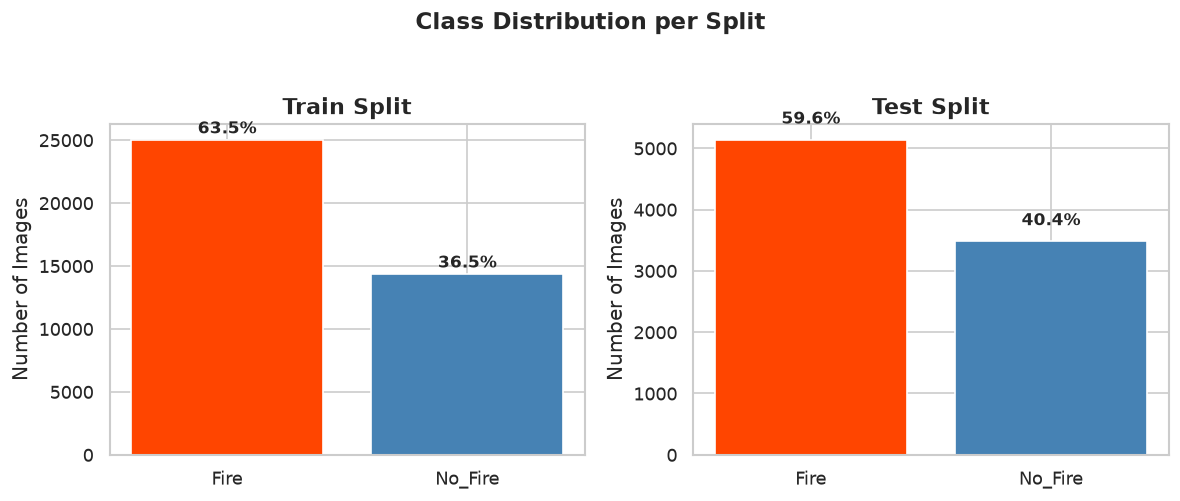

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, split in zip(axes, ["Train", "Test"]):
    sub = df_counts[df_counts["Split"] == split]
    bars = ax.bar(sub["Class"], sub["Count"], color=["orangered", "steelblue"], edgecolor="white")
    for bar, pct in zip(bars, sub["Pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"{split} Split", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Images")

fig.suptitle("Class Distribution per Split", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


### ***Sample Images***

Grid 2x8: baris atas Fire, baris bawah No_Fire dari training set.

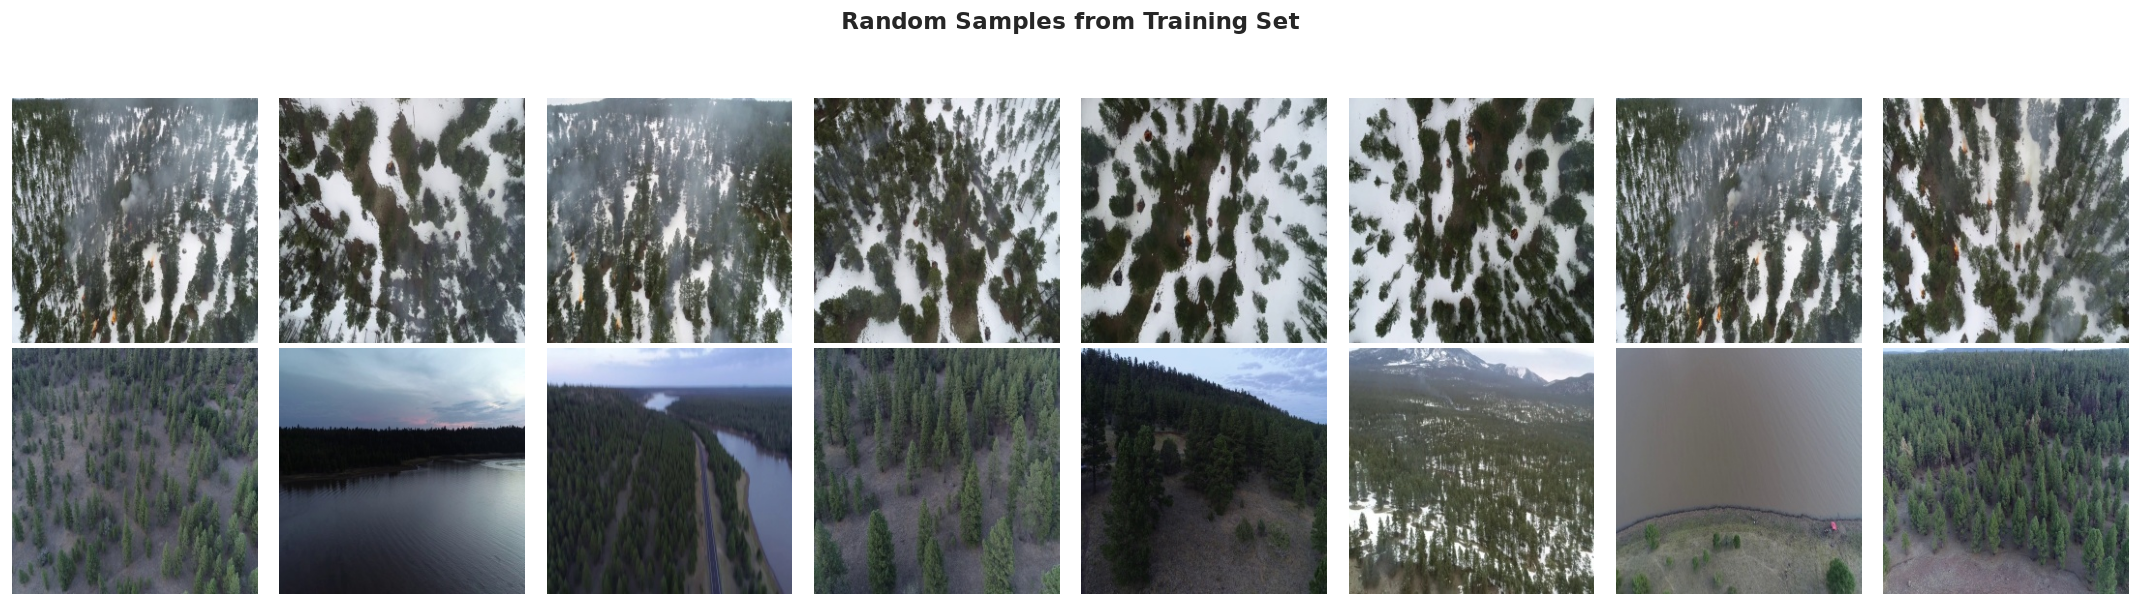

In [5]:
rng = np.random.default_rng(CONFIG["SEED"])

def pick_samples(file_list, n=8):
    chosen = rng.choice(file_list, size=min(n, len(file_list)), replace=False)
    return [np.array(Image.open(f)) for f in chosen]

fire_samples    = pick_samples(train_fire_files, n=8)
nofire_samples  = pick_samples(train_nofire_files, n=8)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    axes[0, i].imshow(fire_samples[i])
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Fire", fontsize=13, fontweight="bold")

    axes[1, i].imshow(nofire_samples[i])
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("No_Fire", fontsize=13, fontweight="bold")

fig.suptitle("Random Samples from Training Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## ***2. Data Splitting (Stratified Train-Val)***

---

Dataset FLAME hanya menyediakan split Training dan Test. Validasi dipisahkan dari Training menggunakan stratified split untuk menjaga proporsi kelas Fire/No_Fire.

In [6]:
train_paths = [(str(p), 1) for p in train_fire_files] + [(str(p), 0) for p in train_nofire_files]
paths_arr  = np.array([p for p, _ in train_paths])
labels_arr = np.array([l for _, l in train_paths], dtype=np.float32)

train_idx, val_idx = train_test_split(
    np.arange(len(paths_arr)),
    test_size=CONFIG["VAL_SIZE"],
    stratify=labels_arr,
    random_state=CONFIG["SEED"],
)

train_files = paths_arr[train_idx]
train_labels = labels_arr[train_idx]
val_files    = paths_arr[val_idx]
val_labels   = labels_arr[val_idx]

test_paths  = [(str(p), 1) for p in test_fire_files] + [(str(p), 0) for p in test_nofire_files]
test_files  = np.array([p for p, _ in test_paths])
test_labels = np.array([l for _, l in test_paths], dtype=np.float32)

print(f"Train:  {len(train_files):>6}  (Fire={int(train_labels.sum())},  No_Fire={len(train_labels) - int(train_labels.sum())})")
print(f"Val:    {len(val_files):>6}  (Fire={int(val_labels.sum())},  No_Fire={len(val_labels) - int(val_labels.sum())})")
print(f"Test:   {len(test_files):>6}  (Fire={int(test_labels.sum())},  No_Fire={len(test_labels) - int(test_labels.sum())})")


Train:   31500  (Fire=20014,  No_Fire=11486)
Val:      7875  (Fire=5004,  No_Fire=2871)
Test:     8617  (Fire=5137,  No_Fire=3480)


## ***3. Dataset & DataLoader***

---

### ***Custom Dataset***

In [7]:
class FlameDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


### ***Transform Pipelines (Torchvision v2)***

Dua pipeline terpisah: train dengan augmentasi spatial + color jitter, eval hanya preprocessing. Semua parameter diambil dari CONFIG.

In [8]:
SIZE = CONFIG["IMAGE_SIZE"]
MEAN = CONFIG["IMAGENET_MEAN"]
STD  = CONFIG["IMAGENET_STD"]

train_transform = T.Compose([
    T.ToImage(),
    T.Resize((SIZE, SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=MEAN, std=STD),
])

eval_transform = T.Compose([
    T.ToImage(),
    T.Resize((SIZE, SIZE)),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=MEAN, std=STD),
])

print("Transform pipelines ready.")
print(f"  Train: Resize({SIZE}) + HFlip + VFlip + ColorJitter + Normalize")
print(f"  Eval:  Resize({SIZE}) + Normalize")


Transform pipelines ready.
  Train: Resize(224) + HFlip + VFlip + ColorJitter + Normalize
  Eval:  Resize(224) + Normalize


### ***DataLoader Instances***

In [9]:
train_dataset = FlameDataset(train_files, train_labels, transform=train_transform)
val_dataset   = FlameDataset(val_files,   val_labels,   transform=eval_transform)
test_dataset  = FlameDataset(test_files,  test_labels,  transform=eval_transform)

BS = CONFIG["BATCH_SIZE"]
NW = CONFIG["NUM_WORKERS"]

train_loader = DataLoader(train_dataset, batch_size=BS, shuffle=True,  num_workers=NW, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BS, shuffle=False, num_workers=NW, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BS, shuffle=False, num_workers=NW, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train batches: 1969
Val batches:   493
Test batches:  539


## ***4. Model Factory***

---

Inisialisasi arsitektur SOTA secara dinamis dari `timm`. Semua model diubah classifier head-nya menjadi 1 logit (binary classification).

In [10]:
def get_model(config):
    name = config["MODEL_NAME"]

    if name == "convnext_v2":
        model = timm.create_model(
            "convnextv2_base.fcmae_ft_in22k_in1k",
            pretrained=True,
            num_classes=1,
        )
    elif name == "swin_v2":
        model = timm.create_model(
            "swinv2_base_window12to16_192to256.ms_in22k_ft_in1k",
            pretrained=True,
            num_classes=1,
        )
    elif name == "internimage":
        model = timm.create_model(
            "internimage_t_1k_224",
            pretrained=True,
            num_classes=1,
        )
    else:
        raise ValueError(f"Model tidak dikenali: {name}")

    return model


model = get_model(CONFIG).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {CONFIG['MODEL_NAME']}")
print(f"  Total params:      {total_params/1e6:.2f}M")
print(f"  Trainable params:  {trainable_params/1e6:.2f}M")


Model: convnext_v2
  Total params:      87.69M
  Trainable params:  87.69M


## ***5. Loss Function***

---

Dua opsi untuk menangani class imbalance: **Focal Loss** (fokus pada hard examples) atau **Balanced BCE** (pos_weight otomatis dari rasio kelas).

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()


def get_loss(config):
    if config["LOSS_TYPE"] == "focal":
        return FocalLoss(
            alpha=config["FOCAL_ALPHA"],
            gamma=config["FOCAL_GAMMA"],
        )
    elif config["LOSS_TYPE"] == "balanced_bce":
        n_fire = train_labels.sum()
        n_nofire = len(train_labels) - n_fire
        pos_weight = torch.tensor([n_nofire / n_fire]).to(device)
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        raise ValueError(f"Loss type tidak dikenali: {config['LOSS_TYPE']}")


criterion = get_loss(CONFIG)
print(f"Loss function: {CONFIG['LOSS_TYPE']}")
if CONFIG["LOSS_TYPE"] == "focal":
    print(f"  alpha = {CONFIG['FOCAL_ALPHA']}, gamma = {CONFIG['FOCAL_GAMMA']}")
else:
    print(f"  pos_weight = {criterion.pos_weight.item():.3f}")


Loss function: focal
  alpha = 0.25, gamma = 2.0


## ***6. Training Loop with AMP & Early Stopping***

---

Automatic Mixed Precision (AMP) via `torch.amp`. Optimizer dengan **split LR** (head > backbone). Scheduler `ReduceLROnPlateau` menurunkan LR saat val F1 stagnan. **Early stopping** menghentikan training jika tidak ada improvement selama `EARLY_STOPPING_PATIENCE` epoch.

### ***Optimizer (Split LR) & Scheduler***

In [12]:
head_param_names = {"head.", "classifier.", "fc."}

head_params = []
backbone_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if any(k in name for k in head_param_names):
        head_params.append(param)
    else:
        backbone_params.append(param)

base_lr = CONFIG["LEARNING_RATE"]
head_lr = base_lr * CONFIG["HEAD_LR_MULTIPLIER"]

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": base_lr},
        {"params": head_params,    "lr": head_lr},
    ],
    weight_decay=CONFIG["WEIGHT_DECAY"],
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    threshold=CONFIG["SCHEDULER_THRESHOLD"],
)

scaler = GradScaler("cuda")

print(f"Optimizer: AdamW")
print(f"  backbone lr  = {base_lr:.1e}")
print(f"  head lr      = {head_lr:.1e}")
print(f"  weight_decay = {CONFIG['WEIGHT_DECAY']}")
print(f"  backbone params: {len(backbone_params)}")
print(f"  head params:     {len(head_params)}")
print(f"\nScheduler: ReduceLROnPlateau")
print(f"  mode=max, factor={CONFIG['SCHEDULER_FACTOR']}, patience={CONFIG['SCHEDULER_PATIENCE']}")
print(f"\nEarly stopping patience: {CONFIG['EARLY_STOPPING_PATIENCE']}")


Optimizer: AdamW
  backbone lr  = 1.0e-04
  head lr      = 1.0e-03
  weight_decay = 0.01
  backbone params: 376
  head params:     4

Scheduler: ReduceLROnPlateau
  mode=max, factor=0.5, patience=5

Early stopping patience: 8


### ***Train / Validate Functions***

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:2d}/{total_epochs} [Train]", leave=False, unit="batch")
    for images, targets in pbar:
        images  = images.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()

        with autocast("cuda" if device.type == "cuda" else "cpu"):
            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs.detach())
        all_preds.extend(probs.cpu().numpy().ravel())
        all_targets.extend(targets.cpu().numpy().ravel())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss  = running_loss / len(loader.dataset)
    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)
    epoch_f1    = f1_score(all_targets, (all_preds > 0.5).astype(int))

    return epoch_loss, epoch_f1


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, total_epochs):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:2d}/{total_epochs} [Val]  ", leave=False, unit="batch")
    for images, targets in pbar:
        images  = images.to(device)
        targets = targets.to(device).unsqueeze(1)

        outputs = model(images)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)
        all_preds.extend(probs.cpu().numpy().ravel())
        all_targets.extend(targets.cpu().numpy().ravel())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss  = running_loss / len(loader.dataset)
    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)
    epoch_f1    = f1_score(all_targets, (all_preds > 0.5).astype(int))

    return epoch_loss, epoch_f1


### ***Execute Training***

In [14]:
OUTPUT_DIR = Path(CONFIG["OUTPUT_DIR"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
best_model_path = OUTPUT_DIR / "best_model.pth"

best_f1 = 0.0
patience_counter = 0
ES_PATIENCE = CONFIG["EARLY_STOPPING_PATIENCE"]

history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": [], "lr": []}

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device,
        epoch, CONFIG["EPOCHS"],
    )
    val_loss, val_f1 = validate(
        model, val_loader, criterion, device,
        epoch, CONFIG["EPOCHS"],
    )

    scheduler.step(val_f1)

    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["lr"].append(lr_now)

    improved = "**" if val_f1 > best_f1 else "  "
    print(
        f"Epoch {epoch:2d}/{CONFIG['EPOCHS']} | "
        f"Train L: {train_loss:.4f}  F1: {train_f1:.4f} | "
        f"Val L: {val_loss:.4f}  F1: {val_f1:.4f} {improved}| LR: {lr_now:.2e}"
    )

    if val_f1 > best_f1 + 1e-6:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    if patience_counter >= ES_PATIENCE:
        print(f"\n  Early stopping triggered after {epoch} epochs "
              f"(no improvement for {ES_PATIENCE} epochs)")
        break

print(f"\nTraining complete. Best validation F1: {best_f1:.4f}")


Epoch  1/25 | Train L: 0.0021  F1: 0.9928 | Val L: 0.0007  F1: 0.9983 **| LR: 1.00e-04


KeyboardInterrupt: 

### ***Training Curves***

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

n_epochs = len(history["train_loss"])

axes[0].plot(history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(history["val_loss"],   label="Val",   marker="o", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend()

axes[1].plot(history["train_f1"], label="Train", marker="o", markersize=3)
axes[1].plot(history["val_f1"],   label="Val",   marker="o", markersize=3)
axes[1].axhline(best_f1, color="green", linestyle="--", alpha=0.5,
                label=f"Best Val F1 = {best_f1:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-Score")
axes[1].set_title("F1-Score", fontweight="bold")
axes[1].legend()

axes[2].plot(history["lr"], marker="o", markersize=3)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate (backbone)", fontweight="bold")
axes[2].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

fig.suptitle("Training Curves", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


## ***7. Test Evaluation & Verification***

---

Muat bobot terbaik, evaluasi pada Test set (kamera Phantom 3), dan tampilkan metrik lengkap.

### ***Load Best Checkpoint & Test Inference***

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

all_probs, all_targets = [], []

with torch.no_grad():
    for images, targets in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy().ravel())
        all_targets.extend(targets.numpy().ravel())

all_probs   = np.array(all_probs)
all_targets = np.array(all_targets)
all_preds   = (all_probs > 0.5).astype(int)

print("Test inference complete.")
print(f"  Samples: {len(all_targets)}")
print(f"  Predicted positives: {all_preds.sum()} ({all_preds.sum()/len(all_preds)*100:.1f}%)")


### ***Classification Report***

In [ ]:
print(classification_report(
    all_targets, all_preds,
    target_names=["No_Fire", "Fire"],
    digits=4,
))


### ***ROC-AUC Score & Confusion Matrix***

In [ ]:
roc_auc = roc_auc_score(all_targets, all_probs)
cm = confusion_matrix(all_targets, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(all_targets, all_probs)
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend(loc="lower right")

# --- Confusion Matrix ---
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No_Fire", "Fire"],
    yticklabels=["No_Fire", "Fire"],
    ax=axes[1],
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix", fontweight="bold")

fig.suptitle(f"Test Set Evaluation  |  ROC-AUC = {roc_auc:.4f}",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix details:")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")
